In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [11]:
# Load dari GitHub
url = "https://raw.githubusercontent.com/farrelrassya/teachingMLDL/main/02.%20Deep%20Learning/04.%20Week%204/Dataset/ReviewTokoBaju.csv"
df = pd.read_csv(url)

# Drop nilai NaN dan ambil kolom yang relevan
df = df[['Review Text', 'Rating']].dropna()

# Label: Rating >= 4 dianggap positif (1), sisanya negatif (0)
df['label'] = df['Rating'].apply(lambda x: 1 if x >= 4 else 0)

# Text dan Label
texts = df['Review Text'].values
print(df['label'].value_counts())


# Tokenisasi
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
padded = pad_sequences(sequences, padding='post', maxlen=200)

# Split data
X_train, X_test, y_train, y_test = train_test_split(padded, labels, test_size=0.2, random_state=42)


label
1    17448
0     5193
Name: count, dtype: int64


In [12]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=10000, output_dim=64, input_length=200),
    tf.keras.layers.SimpleRNN(64, return_sequences=False),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_1 (SimpleRNN)             │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(X_train, y_train, epochs=10, batch_size=64,
                    validation_data=(X_test, y_test))


Epoch 1/10
283/283 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.7730 - auc: 0.4992 - loss: 0.5406 - val_accuracy: 0.7693 - val_auc: 0.5000 - val_loss: 0.5425
Epoch 2/10
283/283 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.7667 - auc: 0.4924 - loss: 0.5461 - val_accuracy: 0.7693 - val_auc: 0.5000 - val_loss: 0.5409
Epoch 3/10
283/283 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.7664 - auc: 0.4873 - loss: 0.5456 - val_accuracy: 0.7693 - val_auc: 0.5000 - val_loss: 0.5402
Epoch 4/10
283/283 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7712 - auc: 0.4894 - loss: 0.5386 - val_accuracy: 0.7693 - val_auc: 0.5000 - val_loss: 0.5418
Epoch 5/10
283/283 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7756 - auc: 0.5006 - loss: 0.5329 - val_accuracy: 0.7693 - val_auc: 0.5000 - val_loss: 0.5402
Epoch 6/10
283/283 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.7728 - auc: 0.4947 - loss: 0.5371 - val_accuracy: 0.7693 - val_auc: 0.5000 - val_loss: 0.5402
Epoch 7/10
283/283 ━━━━━━━━━━━━━

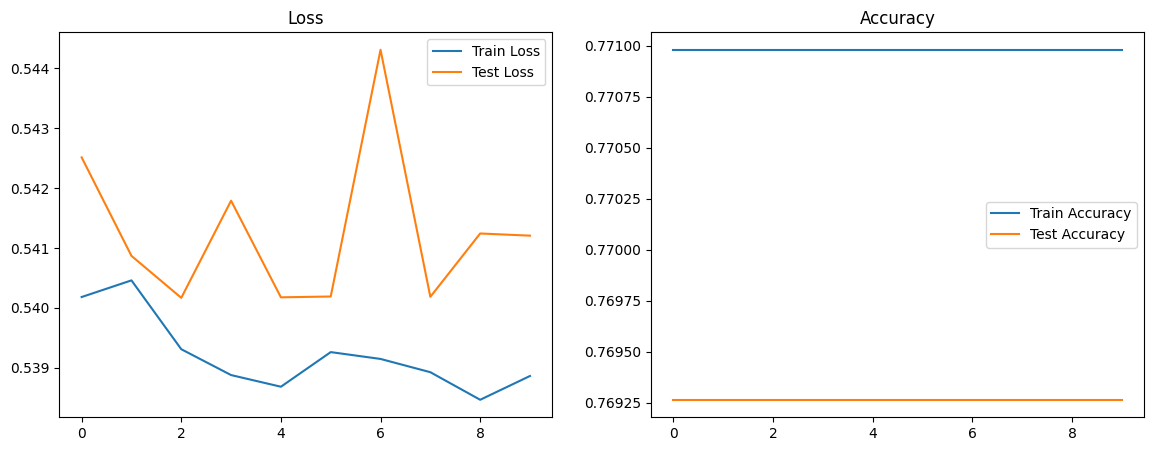

In [14]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Accuracy')
plt.legend()

plt.show()


In [15]:
# Akurasi pada Training dan Testing Set dalam bentuk persentase
train_acc = history.history['accuracy'][-1] * 100
test_acc = history.history['val_accuracy'][-1] * 100

print(f"\n📊 Akurasi Akhir:")
print(f"✅ Training Accuracy : {train_acc:.2f}%")
print(f"✅ Testing Accuracy  : {test_acc:.2f}%")
print(f"Presisi   : {prec:.2f}")
print(f"Recall    : {rec:.2f}")
print(f"F1-Score  : {f1:.2f}")
print(f"AUC       : {auc:.2f}")



📊 Akurasi Akhir:
✅ Training Accuracy : 77.10%
✅ Testing Accuracy  : 76.93%
Presisi   : 0.77
Recall    : 1.00
F1-Score  : 0.87
AUC       : 0.48


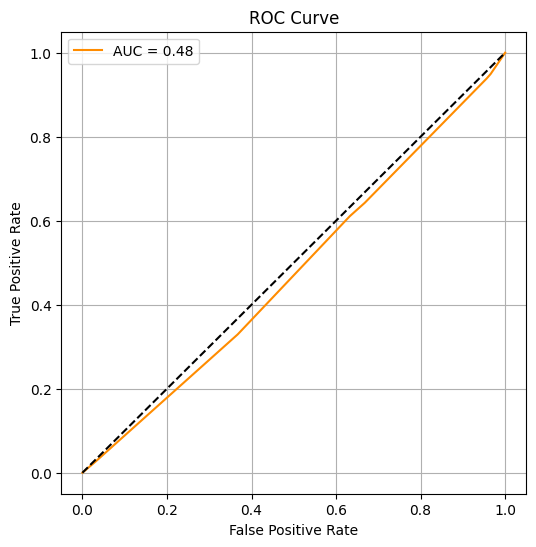

In [16]:
fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}", color='darkorange')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()


## 🧮 Persamaan Matematika dalam Model RNN

RNN (Recurrent Neural Network) adalah model deep learning yang digunakan untuk memproses **urutan data**, seperti kalimat atau teks ulasan. Keunikan RNN terletak pada kemampuannya untuk **mengingat konteks sebelumnya** melalui _hidden state_.


### 1. Hidden State Update

Pada setiap langkah waktu \( t \), RNN memperbarui hidden state berdasarkan input saat ini \( x_t \) dan hidden state sebelumnya \( h_{t-1} \):

$$
h_t = \tanh(W_{xh} \cdot x_t + W_{hh} \cdot h_{t-1} + b_h)
$$

- \( h_t \): hidden state pada waktu \( t \)  
- \( x_t \): input token pada waktu \( t \)  
- \( W_{xh} \): bobot dari input ke hidden state  
- \( W_{hh} \): bobot dari hidden state sebelumnya  
- \( b_h \): bias untuk hidden layer  
- \( \tanh \): fungsi aktivasi nonlinear (hasil antara -1 dan 1)


### 2. Output Layer (Prediksi)

Setelah seluruh input diproses, hidden state terakhir digunakan untuk menghasilkan output prediksi:

$$
\hat{y} = \sigma(W_{hy} \cdot h_T + b_y)
$$

- \( \hat{y} \): prediksi akhir (probabilitas positif)  
- \( h_T \): hidden state terakhir pada urutan input  
- \( W_{hy} \): bobot dari hidden ke output  
- \( b_y \): bias pada layer output  
- \( \sigma \): fungsi sigmoid, menghasilkan output antara 0 dan 1

### 3. Binary Cross-Entropy Loss

Fungsi loss yang digunakan untuk klasifikasi biner (positif/negatif):

$$
\mathcal{L}_{BCE} = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \cdot \log(\hat{y}_i) + (1 - y_i) \cdot \log(1 - \hat{y}_i) \right]
$$

- \( y_i \): label sebenarnya (0 atau 1)  
- \( \hat{y}_i \): prediksi probabilitas  
- \( N \): jumlah data


### 4. Backpropagation Through Time (BPTT)

Karena RNN bekerja dengan urutan, proses pelatihan dilakukan melalui **Backpropagation Through Time**, di mana gradien dihitung sepanjang waktu:

$$
\frac{\partial \mathcal{L}}{\partial W} = \sum_{t=1}^{T} \frac{\partial \mathcal{L}}{\partial h_t} \cdot \frac{\partial h_t}{\partial W}
$$

Backpropagation dilakukan ke seluruh waktu untuk memperbarui bobot model.

---


## 📐 Persamaan Matematika

### 1. **Binary Cross-Entropy Loss**
Digunakan sebagai fungsi loss untuk klasifikasi biner.

$$
\mathcal{L}_{BCE} = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \cdot \log(\hat{y}_i) + (1 - y_i) \cdot \log(1 - \hat{y}_i) \right]
$$

- \( y_i \): label asli (0 atau 1)  
- \( \hat{y}_i \): output prediksi (probabilitas dari sigmoid)  
- \( N \): jumlah sampel  
- Tujuan: meminimalkan kesalahan antara prediksi dan label asli

### 2. **Akurasi**
Mengukur jumlah prediksi yang benar dibandingkan total prediksi.

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

- TP: True Positive  
- TN: True Negative  
- FP: False Positive  
- FN: False Negative

### 3. **Presisi (Precision)**
Seberapa akurat model saat memprediksi kelas positif.

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

### 4. **Recall (Sensitivitas)**
Seberapa baik model mendeteksi semua data yang benar-benar positif.

$$
\text{Recall} = \frac{TP}{TP + FN}
$$


### 5. **F1 Score**
Rata-rata harmonik antara Precision dan Recall.

$$
F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

### 6. **ROC Curve & AUC**
ROC (Receiver Operating Characteristic) menunjukkan keseimbangan antara TPR dan FPR.

$$
\text{TPR} = \frac{TP}{TP + FN}, \quad
\text{FPR} = \frac{FP}{FP + TN}
$$

AUC (Area Under Curve) mengukur seberapa baik model membedakan kelas:  
- AUC = 1.0 → sempurna  
- AUC = 0.5 → tidak lebih baik dari tebak-tebakan

---

## 📈 Visualisasi

### ✅ Grafik Loss dan Akurasi
- Kurva loss digunakan untuk melihat performa model dalam mempelajari data.
- Kurva akurasi menunjukkan performa klasifikasi model.

### ✅ ROC Curve
- Digunakan untuk mengevaluasi keseimbangan sensitivitas dan spesifisitas model pada berbagai threshold.
- Semakin melengkung ke kiri atas, semakin baik modelnya.


